# OCR 도구 비교와 Layout-aware 구조화 실험

영수증/문서 이미지에서 OCR 결과를 비교하고, 추출된 텍스트를 구조화해서 `상호명`, `금액`, `VAT`, `합계` 후보를 판단합니다.

비교 대상:

1. Tesseract OCR
2. EasyOCR
3. PaddleOCR
4. Layout Parser 기반 layout-aware 후처리

주의: Layout Parser는 OCR 엔진 자체라기보다 레이아웃 인식/후처리 프레임워크에 가깝습니다. 여기서는 OCR 결과를 좌표 기반 row/block으로 재구성하는 네 번째 비교 축으로 사용합니다.

## 0. 설치

필요 패키지가 없으면 아래 셀을 실행합니다. Tesseract는 별도 시스템 설치가 필요합니다.

macOS 예시:

```bash
brew install tesseract tesseract-lang
pip install pytesseract opencv-python matplotlib easyocr paddleocr layoutparser
```

In [1]:
from __future__ import annotations

import importlib.util
import json
import os
import re
import shutil
import subprocess
from dataclasses import dataclass
from pathlib import Path
from typing import Any

PROJECT_ROOT_GUESS = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.environ.setdefault("PADDLE_PDX_CACHE_HOME", str(PROJECT_ROOT_GUESS / "data" / "paddlex_cache"))
os.environ.setdefault("MPLCONFIGDIR", str(PROJECT_ROOT_GUESS / "data" / "matplotlib_cache"))
os.environ.setdefault("XDG_CACHE_HOME", str(PROJECT_ROOT_GUESS / "data" / "xdg_cache"))
Path(os.environ["PADDLE_PDX_CACHE_HOME"]).mkdir(parents=True, exist_ok=True)
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)
Path(os.environ["XDG_CACHE_HOME"]).mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd
from PIL import Image, ImageDraw


def has_module(name: str) -> bool:
    return importlib.util.find_spec(name) is not None


modules = ["pytesseract", "easyocr", "paddleocr", "layoutparser", "cv2", "matplotlib"]
for module in modules:
    print(f"{module:14s}: {has_module(module)}")

print(f"tesseract bin : {shutil.which('tesseract')}")

pytesseract   : True
easyocr       : True
paddleocr     : True
layoutparser  : True
cv2           : True
matplotlib    : True
tesseract bin : /opt/homebrew/bin/tesseract


## 1. 테스트 이미지 선택

In [2]:
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
IMG_DIR = PROJECT_ROOT / "docs" / "imgs"
IMAGE_PATHS = sorted([p for p in IMG_DIR.glob("*") if p.suffix.lower() in {".png", ".jpg", ".jpeg"}])

for i, path in enumerate(IMAGE_PATHS):
    image = Image.open(path)
    print(i, path.name, image.size)

TEST_IMAGE_PATH = IMAGE_PATHS[0]
TEST_IMAGE_PATH

0 KakaoTalk_Photo_2026-05-19-21-14-02 001.png (1206, 2622)
1 KakaoTalk_Photo_2026-05-19-21-14-03 002.jpeg (5712, 4284)
2 KakaoTalk_Photo_2026-05-19-21-14-03 003.jpeg (4032, 3024)
3 KakaoTalk_Photo_2026-05-19-21-14-06 004.jpeg (5712, 4284)
4 KakaoTalk_Photo_2026-05-19-21-14-09 005.jpeg (5712, 4284)


PosixPath('/Users/judy/Desktop/github/mo_du_yeon/Advanced-RAG-Multimodal-AI-Agent/docs/imgs/KakaoTalk_Photo_2026-05-19-21-14-02 001.png')

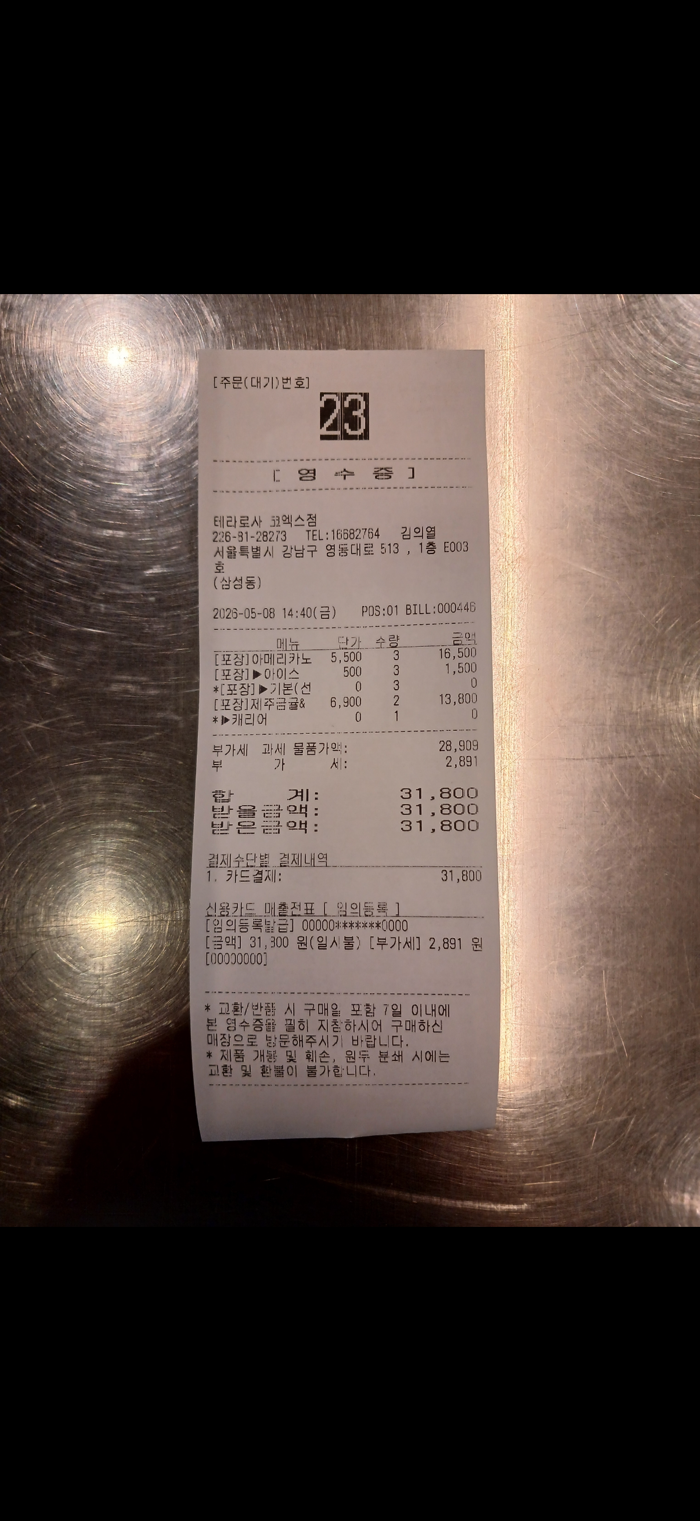

In [3]:
image = Image.open(TEST_IMAGE_PATH).convert("RGB")
display(image.resize((min(700, image.width), int(image.height * min(700, image.width) / image.width))))

## 2. 이미지 전처리

OCR 엔진별 공정 비교를 위해 기본 전처리 이미지를 하나 만듭니다. 원본과 전처리본을 둘 다 테스트해도 좋습니다.

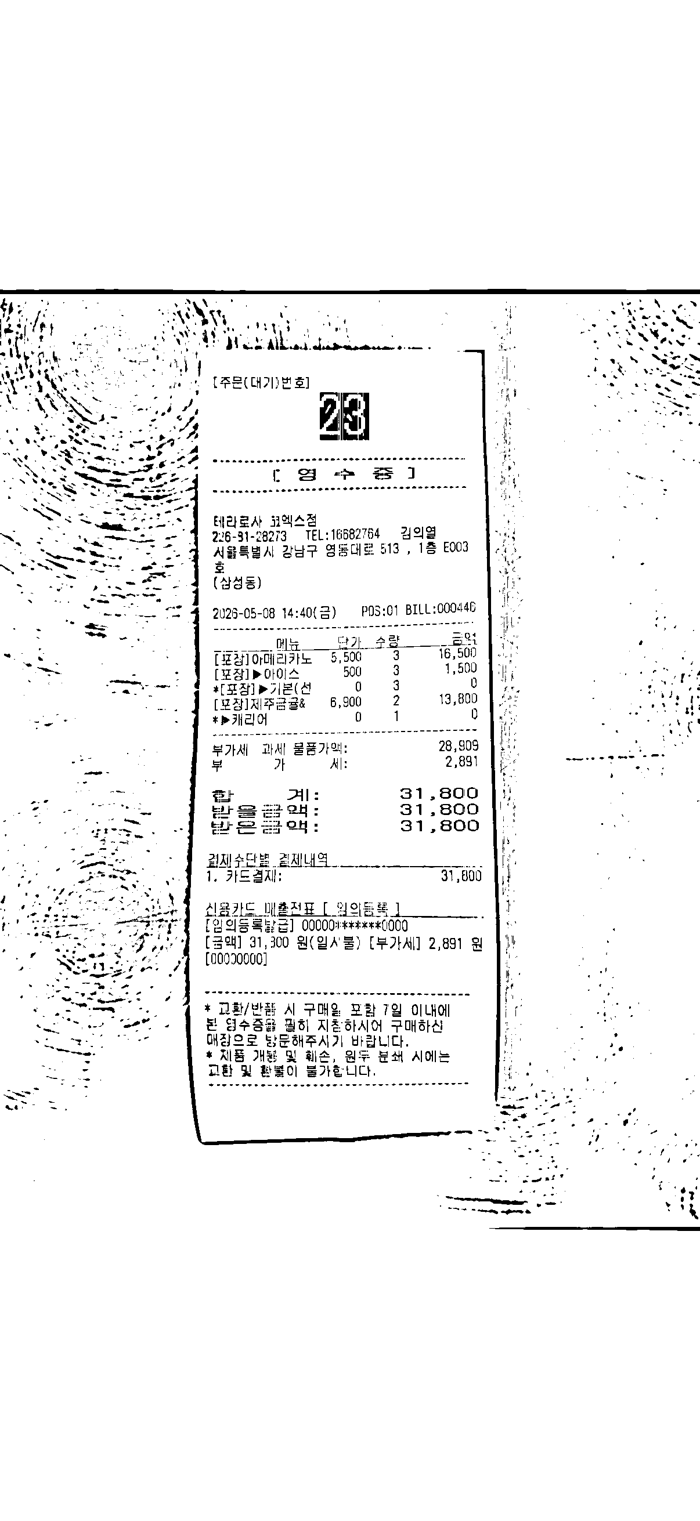

In [8]:
def preprocess_for_ocr(path: Path, max_width: int = 1600) -> Image.Image:
    image = Image.open(path).convert("RGB")
    if image.width > max_width:
        ratio = max_width / image.width
        image = image.resize((max_width, int(image.height * ratio)))

    if has_module("cv2"):
        import cv2

        arr = np.array(image)
        gray = cv2.cvtColor(arr, cv2.COLOR_RGB2GRAY)
        gray = cv2.bilateralFilter(gray, 7, 50, 50)
        binary = cv2.adaptiveThreshold(
            gray,
            255,
            cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
            cv2.THRESH_BINARY,
            31,
            9,
        )
        return Image.fromarray(binary).convert("RGB")

    return image.convert("L").convert("RGB")


ocr_image = preprocess_for_ocr("/Users/judy/Desktop/github/mo_du_yeon/Advanced-RAG-Multimodal-AI-Agent/docs/imgs/KakaoTalk_Photo_2026-05-19-21-14-02 001.png")
display(ocr_image.resize((min(700, ocr_image.width), int(ocr_image.height * min(700, ocr_image.width) / ocr_image.width))))

## 3. 공통 결과 스키마

OCR 도구마다 결과 형식이 다르므로 아래 컬럼으로 통일합니다.

- `engine`: OCR 도구 이름
- `text`: 인식 텍스트
- `conf`: confidence
- `x1`, `y1`, `x2`, `y2`: bounding box
- `cx`, `cy`: 중심 좌표

In [9]:
OCR_COLUMNS = ["engine", "text", "conf", "x1", "y1", "x2", "y2", "cx", "cy", "width", "height"]


def normalize_box(engine: str, text: str, conf: float | None, box: tuple[float, float, float, float]) -> dict[str, Any]:
    x1, y1, x2, y2 = box
    return {
        "engine": engine,
        "text": str(text).strip(),
        "conf": None if conf is None else float(conf),
        "x1": float(x1),
        "y1": float(y1),
        "x2": float(x2),
        "y2": float(y2),
        "cx": float((x1 + x2) / 2),
        "cy": float((y1 + y2) / 2),
        "width": float(x2 - x1),
        "height": float(y2 - y1),
    }


def as_df(rows: list[dict[str, Any]]) -> pd.DataFrame:
    if not rows:
        return pd.DataFrame(columns=OCR_COLUMNS)
    df = pd.DataFrame(rows)
    df = df[df["text"].astype(str).str.len() > 0].copy()
    return df[OCR_COLUMNS].sort_values(["y1", "x1"]).reset_index(drop=True)

## 4. Tesseract OCR

In [10]:
def run_tesseract(image: Image.Image, lang: str = "kor+eng") -> pd.DataFrame:
    if not has_module("pytesseract"):
        print("pytesseract가 설치되어 있지 않습니다.")
        return as_df([])

    import pytesseract

    data = pytesseract.image_to_data(
        image,
        lang=lang,
        config="--oem 3 --psm 6",
        output_type=pytesseract.Output.DATAFRAME,
    )
    rows = []
    for _, row in data.dropna(subset=["text"]).iterrows():
        text = str(row["text"]).strip()
        if not text:
            continue
        conf = float(row["conf"]) if row["conf"] != -1 else None
        x1, y1 = row["left"], row["top"]
        x2, y2 = x1 + row["width"], y1 + row["height"]
        rows.append(normalize_box("tesseract", text, conf, (x1, y1, x2, y2)))
    return as_df(rows)

ocr_image = preprocess_for_ocr("/Users/judy/Desktop/github/mo_du_yeon/Advanced-RAG-Multimodal-AI-Agent/docs/imgs/KakaoTalk_Photo_2026-05-19-21-14-02 001.png")

tesseract_df = run_tesseract(ocr_image)
tesseract_df.head(30)

,engine,text,conf,x1,y1,x2,y2,cx,cy,width,height
0,tesseract,년,33.301392,0.0,498.0,1206.0,521.0,603.0,509.5,1206.0,23.0
1,tesseract,23),54.270180,0.0,550.0,45.0,584.0,22.5,567.0,45.0,34.0
2,tesseract,ft,20.552963,69.0,555.0,92.0,579.0,80.5,567.0,23.0,24.0
3,tesseract,니그,34.634190,456.0,557.0,532.0,582.0,494.0,569.5,76.0,25.0
4,tesseract,우호,32.498951,325.0,562.0,416.0,592.0,370.5,577.0,91.0,30.0
5,tesseract,1,22.960434,145.0,564.0,166.0,580.0,155.5,572.0,21.0,16.0
6,tesseract,에도,17.582674,578.0,565.0,601.0,582.0,589.5,573.5,23.0,17.0
7,tesseract,AMS,21.350002,1000.0,566.0,1158.0,594.0,1079.0,580.0,158.0,28.0
8,tesseract,으나,28.788223,205.0,569.0,209.0,580.0,207.0,574.5,4.0,11.0
9,tesseract,a,70.035378,863.0,570.0,880.0,584.0,871.5,577.0,17.0,14.0


## 5. EasyOCR

In [11]:
def run_easyocr(image: Image.Image) -> pd.DataFrame:
    if not has_module("easyocr"):
        print("easyocr가 설치되어 있지 않습니다.")
        return as_df([])

    import easyocr

    easyocr_model_dir = PROJECT_ROOT / "data" / "easyocr_models"
    easyocr_user_network_dir = PROJECT_ROOT / "data" / "easyocr_user_network"
    easyocr_model_dir.mkdir(parents=True, exist_ok=True)
    easyocr_user_network_dir.mkdir(parents=True, exist_ok=True)

    try:
        reader = easyocr.Reader(
            ["ko", "en"],
            gpu=False,
            model_storage_directory=str(easyocr_model_dir),
            user_network_directory=str(easyocr_user_network_dir),
        )
        result = reader.readtext(np.array(image))
    except Exception as exc:
        print(f"EasyOCR 실행 실패: {type(exc).__name__}: {exc}")
        return as_df([])
    rows = []
    for box_points, text, conf in result:
        xs = [point[0] for point in box_points]
        ys = [point[1] for point in box_points]
        rows.append(normalize_box("easyocr", text, conf, (min(xs), min(ys), max(xs), max(ys))))
    return as_df(rows)


easyocr_df = run_easyocr(ocr_image)
easyocr_df.head(30)

Using CPU. Note: This module is much faster with a GPU.
/Users/judy/Desktop/github/mo_du_yeon/Advanced-RAG-Multimodal-AI-Agent/venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


,engine,text,conf,x1,y1,x2,y2,cx,cy,width,height
0,easyocr,[주문(대기} 번호],0.518301,362.0,645.0,538.0,677.0,450.0,661.0,176.0,32.0
1,easyocr,"영 ""수 존 ]",0.154988,510.0,798.0,718.0,831.0,614.0,814.5,208.0,33.0
2,easyocr,테라로사 둘텍스점,0.138231,363.0,879.0,550.0,917.0,456.5,898.0,187.0,38.0
3,easyocr,김의열,0.694103,686.0,903.0,755.0,936.0,720.5,919.5,69.0,33.0
4,easyocr,TEL: 1ti682764,0.587046,522.0,905.0,659.0,936.0,590.5,920.5,137.0,31.0
5,easyocr,26-31-28273,0.903807,362.0,909.0,497.0,938.0,429.5,923.5,135.0,29.0
6,easyocr,1층 E00J,0.466790,712.0,927.0,814.0,960.0,763.0,943.5,102.0,33.0
7,easyocr,서울특별시 강남구 영뚱대로 513,0.169348,363.0,929.0,693.0,969.0,528.0,949.0,330.0,40.0
8,easyocr,호,0.998789,367.0,963.0,388.0,990.0,377.5,976.5,21.0,27.0
9,easyocr,(삼성동),0.983694,364.0,989.0,454.0,1022.0,409.0,1005.5,90.0,33.0


## 6. PaddleOCR

In [ ]:
def run_paddleocr(image: Image.Image) -> pd.DataFrame:
    if not has_module("paddleocr"):
        print("paddleocr가 설치되어 있지 않습니다.")
        return as_df([])

    from paddleocr import PaddleOCR

    try:
        try:
            ocr = PaddleOCR(lang="korean", use_textline_orientation=True)
        except TypeError:
            ocr = PaddleOCR(lang="korean")
    except Exception as exc:
        print(f"PaddleOCR 초기화 실패: {type(exc).__name__}: {exc}")
        return as_df([])

    try:
        try:
            result = ocr.ocr(np.array(image))
        except Exception:
            result = ocr.predict(np.array(image))
    except Exception as exc:
        print(f"PaddleOCR 실행 실패: {type(exc).__name__}: {exc}")
        return as_df([])
    rows = []

    # PaddleOCR 3.x can return dict-like OCRResult objects.
    for page in result:
        if isinstance(page, dict) or hasattr(page, "get"):
            texts = page.get("rec_texts", [])
            scores = page.get("rec_scores", [])
            boxes = page.get("rec_boxes", None)
            if boxes is None:
                boxes = page.get("dt_polys", [])
            for text, conf, box_points in zip(texts, scores, boxes):
                arr = np.array(box_points)
                if arr.ndim == 1 and len(arr) == 4:
                    x1, y1, x2, y2 = arr.tolist()
                else:
                    x1, y1 = arr[:, 0].min(), arr[:, 1].min()
                    x2, y2 = arr[:, 0].max(), arr[:, 1].max()
                rows.append(normalize_box("paddleocr", text, conf, (x1, y1, x2, y2)))
            continue

    for page in result:
        if isinstance(page, dict) or hasattr(page, "get"):
            continue
        if not page:
            continue
        for item in page:
            box_points = item[0]
            text, conf = item[1]
            xs = [point[0] for point in box_points]
            ys = [point[1] for point in box_points]
            rows.append(normalize_box("paddleocr", text, conf, (min(xs), min(ys), max(xs), max(ys))))
    return as_df(rows)


paddleocr_df = run_paddleocr(ocr_image)
paddleocr_df.head(30)

/Users/judy/Desktop/github/mo_du_yeon/Advanced-RAG-Multimodal-AI-Agent/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/judy/Desktop/github/mo_du_yeon/Advanced-RAG-Multimodal-AI-Agent/venv/lib/python3.11/site-packages/paddle/utils/cpp_extension/extension_utils.py:712: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
Creating model: ('PP-LCNet_x1_0_doc_ori', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/Users/judy/Desktop/github/mo_du_yeon/Advanced-RAG-Multimodal-AI-Agent/data/paddlex_cache/official_models/PP-LCNet_x1_0_doc_ori`.
Creating model: (

## 7. Layout Parser 기반 layout-aware 결과

여기서는 Layout Parser를 OCR 결과의 좌표 구조를 다루는 레이어로 사용합니다. 별도 layout detection 모델을 붙이기 전 단계로, Tesseract 결과를 `TextBlock`처럼 다루고 row 단위로 묶어봅니다.

In [ ]:
def run_layoutparser_like(image: Image.Image) -> pd.DataFrame:
    base_df = run_tesseract(image)
    if base_df.empty:
        return as_df([])

    engine_name = "layoutparser"
    if has_module("layoutparser"):
        import layoutparser as lp

        _ = [
            lp.TextBlock(
                lp.Rectangle(row.x1, row.y1, row.x2, row.y2),
                text=row.text,
                score=row.conf,
            )
            for row in base_df.itertuples()
        ]

    layout_df = base_df.copy()
    layout_df["engine"] = engine_name
    return layout_df


layoutparser_df = run_layoutparser_like(ocr_image)
layoutparser_df.head(30)

## 8. OCR 결과 시각화

In [ ]:
def draw_boxes(image: Image.Image, df: pd.DataFrame, max_boxes: int = 80) -> Image.Image:
    canvas = image.copy().convert("RGB")
    draw = ImageDraw.Draw(canvas)
    for row in df.head(max_boxes).itertuples():
        draw.rectangle([row.x1, row.y1, row.x2, row.y2], outline="red", width=2)
        draw.text((row.x1, max(0, row.y1 - 12)), str(row.text)[:20], fill="blue")
    return canvas


for name, df in {
    "tesseract": tesseract_df,
    "easyocr": easyocr_df,
    "paddleocr": paddleocr_df,
    "layoutparser": layoutparser_df,
}.items():
    print(name, len(df))
    if not df.empty:
        display(draw_boxes(ocr_image, df).resize((min(700, ocr_image.width), int(ocr_image.height * min(700, ocr_image.width) / ocr_image.width))))

## 9. Layout 패턴 기반 구조화

OCR 결과를 좌표 기준으로 row 단위로 묶고, 키워드와 금액 패턴을 이용해 필드를 추정합니다.

In [ ]:
AMOUNT_RE = re.compile(r"(?<!\d)(?:\d{1,3}(?:,\d{3})+|\d{4,})(?!\d)")
VAT_KEYWORDS = ["부가세", "부가가치세", "VAT", "세액", "과세"]
TOTAL_KEYWORDS = ["합계", "총액", "총 합계", "결제금액", "승인금액", "받을금액", "청구금액", "판매금액"]
BUSINESS_EXCLUDE = ["영수증", "카드", "승인", "합계", "금액", "부가세", "VAT", "전화", "TEL", "사업자", "대표"]


def parse_amount(text: str) -> int | None:
    matches = AMOUNT_RE.findall(text.replace(" ", ""))
    if not matches:
        return None
    return max(int(m.replace(",", "")) for m in matches)


def group_rows(df: pd.DataFrame, y_tolerance: float = 18) -> pd.DataFrame:
    if df.empty:
        return pd.DataFrame(columns=["row_id", "text", "x1", "y1", "x2", "y2", "amount"])

    sorted_df = df.sort_values(["cy", "x1"]).copy()
    rows = []
    current = []
    current_y = None

    for item in sorted_df.itertuples():
        if current_y is None or abs(item.cy - current_y) <= y_tolerance:
            current.append(item)
            current_y = item.cy if current_y is None else (current_y + item.cy) / 2
        else:
            rows.append(current)
            current = [item]
            current_y = item.cy
    if current:
        rows.append(current)

    normalized_rows = []
    for row_id, items in enumerate(rows):
        items = sorted(items, key=lambda x: x.x1)
        text = " ".join(str(item.text) for item in items)
        normalized_rows.append(
            {
                "row_id": row_id,
                "text": text,
                "x1": min(item.x1 for item in items),
                "y1": min(item.y1 for item in items),
                "x2": max(item.x2 for item in items),
                "y2": max(item.y2 for item in items),
                "amount": parse_amount(text),
            }
        )
    return pd.DataFrame(normalized_rows)


def classify_receipt_fields(df: pd.DataFrame) -> dict[str, Any]:
    rows = group_rows(df)
    if rows.empty:
        return {"business_name": None, "vat_amount": None, "total_amount": None, "amount_candidates": [], "rows": rows}

    amount_rows = rows[rows["amount"].notna()].copy()
    amount_candidates = amount_rows[["row_id", "text", "amount"]].to_dict("records")

    vat_rows = rows[rows["text"].str.contains("|".join(VAT_KEYWORDS), case=False, regex=True, na=False)].copy()
    total_rows = rows[rows["text"].str.contains("|".join(TOTAL_KEYWORDS), case=False, regex=True, na=False)].copy()

    vat_amount = None
    if not vat_rows.empty:
        vat_amount = vat_rows["amount"].dropna().max() if vat_rows["amount"].notna().any() else None

    total_amount = None
    if not total_rows.empty and total_rows["amount"].notna().any():
        total_amount = total_rows["amount"].dropna().max()
    elif not amount_rows.empty:
        total_amount = amount_rows["amount"].max()

    top_rows = rows.sort_values("y1").head(8)
    business_name = None
    for text in top_rows["text"].astype(str):
        has_digit = bool(re.search(r"\d", text))
        excluded = any(keyword.lower() in text.lower() for keyword in BUSINESS_EXCLUDE)
        if len(text.strip()) >= 2 and not has_digit and not excluded:
            business_name = text.strip()
            break

    return {
        "business_name": business_name,
        "vat_amount": None if pd.isna(vat_amount) else int(vat_amount),
        "total_amount": None if pd.isna(total_amount) else int(total_amount),
        "amount_candidates": amount_candidates,
        "rows": rows,
    }

## 10. 4개 결과 비교

In [ ]:
ocr_results = {
    "tesseract": tesseract_df,
    "easyocr": easyocr_df,
    "paddleocr": paddleocr_df,
    "layoutparser": layoutparser_df,
}

summary_rows = []
structured_results = {}

for engine, df in ocr_results.items():
    structured = classify_receipt_fields(df)
    structured_results[engine] = structured
    summary_rows.append(
        {
            "engine": engine,
            "text_blocks": len(df),
            "amount_candidate_count": len(structured["amount_candidates"]),
            "business_name_candidate": structured["business_name"],
            "vat_amount_candidate": structured["vat_amount"],
            "total_amount_candidate": structured["total_amount"],
        }
    )

comparison_df = pd.DataFrame(summary_rows)
comparison_df

In [ ]:
for engine, structured in structured_results.items():
    print("=" * 80)
    print(engine)
    print("business_name:", structured["business_name"])
    print("vat_amount:", structured["vat_amount"])
    print("total_amount:", structured["total_amount"])
    print("\nrow preview")
    display(structured["rows"].head(25))
    print("\namount candidates")
    display(pd.DataFrame(structured["amount_candidates"]).head(25))

## 11. 전체 이미지 일괄 테스트

아래 셀은 `docs/imgs`의 모든 이미지를 Tesseract 기준으로 빠르게 돌려보고 구조화 결과를 모읍니다. EasyOCR/PaddleOCR는 모델 로딩 시간이 길 수 있어 필요할 때만 확장하세요.

In [ ]:
batch_rows = []

for path in IMAGE_PATHS:
    img = preprocess_for_ocr(path)
    df = run_tesseract(img)
    structured = classify_receipt_fields(df)
    batch_rows.append(
        {
            "image": path.name,
            "text_blocks": len(df),
            "business_name_candidate": structured["business_name"],
            "vat_amount_candidate": structured["vat_amount"],
            "total_amount_candidate": structured["total_amount"],
        }
    )

batch_df = pd.DataFrame(batch_rows)
batch_df

## 12. 다음 실험 방향

- 수동 정답 라벨을 만들어 OCR별 정확도를 비교합니다.
- `상호명`, `VAT`, `합계`, `공급가액`, `카드 승인번호` 같은 필드를 schema로 고정합니다.
- row의 오른쪽 끝에 있는 숫자를 금액 후보로 보는 layout rule을 강화합니다.
- 영수증 종류별 layout template을 만듭니다.
- Layout Parser에 Detectron2 기반 문서 레이아웃 모델을 붙여 `text`, `table`, `figure` 영역을 먼저 분리합니다.
- OCR 결과를 RAG 문서로 넣을 때는 `field_type`, `bbox`, `row_id`, `image_name` metadata를 함께 저장합니다.